Sales Performance Analysis

To analyze sales data and identify trends, high-performing regions, and profitable categories.

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
# Load dataset
df = pd.read_csv("superstore_dataset.csv")


In [54]:
# Display data
df.head()

,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
0,US-2020-103800,1/3/2019,1/7/2019,Darren Powers,Message Book,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Consumer,Office Supplies,Paper,Central,77095,Houston,Texas,United States,0.2,5.5512,2,16.448,0.3375
1,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,GBC,GBC Standard Plastic Binding Systems Combs,Home Office,Office Supplies,Binders,Central,60540,Naperville,Illinois,United States,0.8,-5.4870,2,3.540,-1.5500
2,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,Avery,Avery 508,Home Office,Office Supplies,Labels,Central,60540,Naperville,Illinois,United States,0.2,4.2717,3,11.784,0.3625
3,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,SAFCO,SAFCO Boltless Steel Shelving,Home Office,Office Supplies,Storage,Central,60540,Naperville,Illinois,United States,0.2,-64.7748,3,272.736,-0.2375
4,US-2020-141817,1/5/2019,1/12/2019,Mick Brown,Avery,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Consumer,Office Supplies,Art,East,19143,Philadelphia,Pennsylvania,United States,0.2,4.8840,3,19.536,0.2500


In [55]:
# Info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       9994 non-null   object 
 1   order_date     9994 non-null   object 
 2   ship_date      9994 non-null   object 
 3   customer       9994 non-null   object 
 4   manufactory    9994 non-null   object 
 5   product_name   9994 non-null   object 
 6   segment        9994 non-null   object 
 7   category       9994 non-null   object 
 8   subcategory    9994 non-null   object 
 9   region         9994 non-null   object 
 10  zip            9994 non-null   int64  
 11  city           9994 non-null   object 
 12  state          9994 non-null   object 
 13  country        9994 non-null   object 
 14  discount       9994 non-null   float64
 15  profit         9994 non-null   float64
 16  quantity       9994 non-null   int64  
 17  sales          9994 non-null   float64
 18  profit_m

In [56]:
# Missing values
df.isnull().sum()

order_id         0
order_date       0
ship_date        0
customer         0
manufactory      0
product_name     0
segment          0
category         0
subcategory      0
region           0
zip              0
city             0
state            0
country          0
discount         0
profit           0
quantity         0
sales            0
profit_margin    0
dtype: int64

In [57]:
# Cleaning
df = df.dropna()


In [60]:
# Convert date
df['order_date'] = pd.to_datetime(df['order_date'])

In [61]:
# KPIs
print("Total Sales:", df['sales'].sum())
print("Total Profit:", df['profit_margin'].sum())
print("Average Sales:", df['sales'].min())

Total Sales: 2297200.8603
Total Profit: 1202.417413639
Average Sales: 0.444


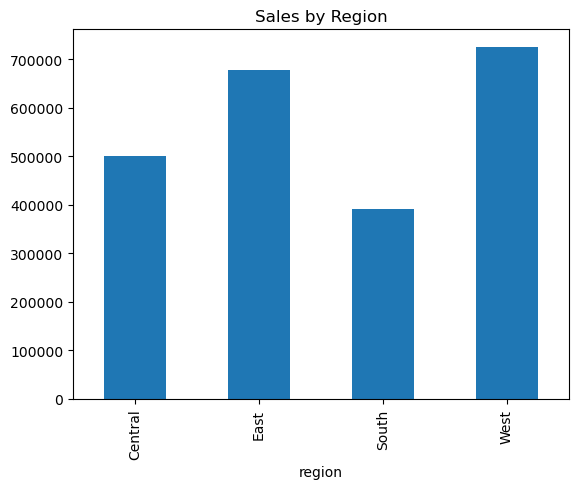

In [62]:
# Sales by region
plt.figure()
df.groupby('region')['sales'].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.show()

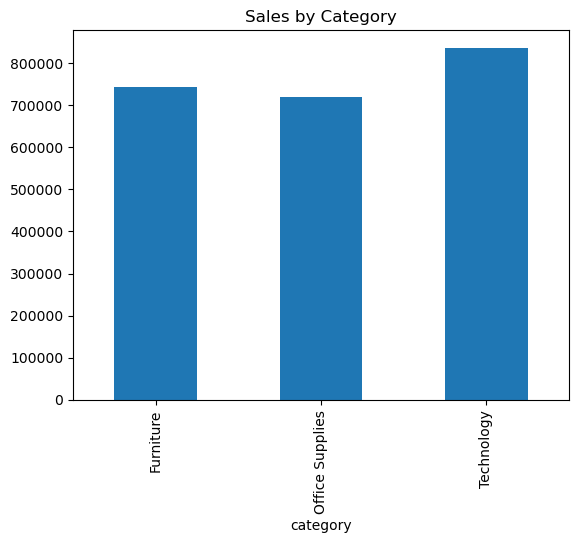

In [63]:
# Sales by category
plt.figure()
df.groupby('category')['sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

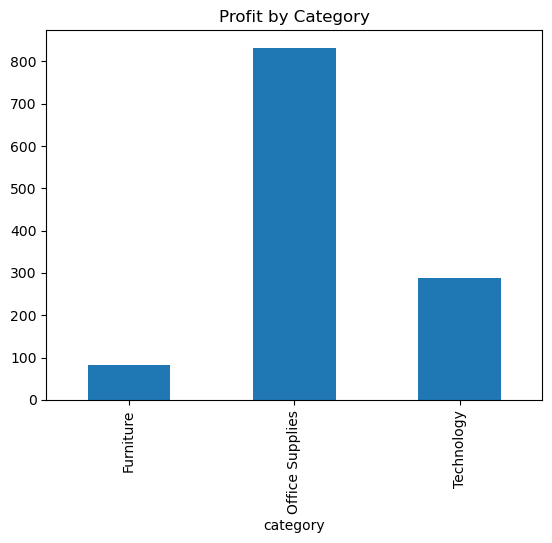

In [64]:
# Profit by category
plt.figure()
df.groupby('category')['profit_margin'].sum().plot(kind='bar')
plt.title("Profit by Category")
plt.show()

C:\Users\ankit\AppData\Local\Temp\ipykernel_24160\408186242.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('order_date')['sales'].resample('M').sum().plot()


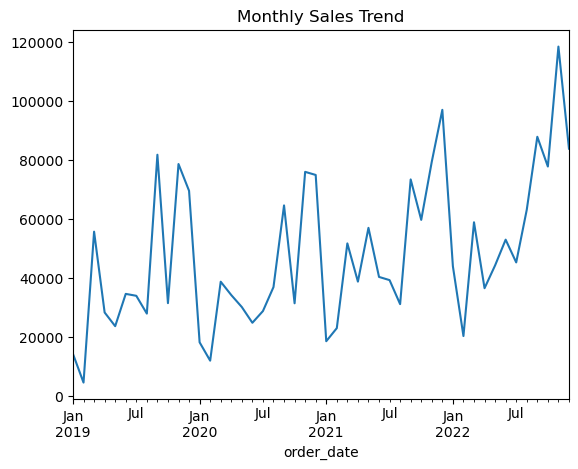

In [65]:

# Monthly sales trend
df.set_index('order_date')['sales'].resample('M').sum().plot()
plt.title("Monthly Sales Trend")
plt.show()


In [66]:
# Top products
print("\nTop Products:")
print(df.groupby('product_name')['sales']
      .sum().sort_values(ascending=False).head())



Top Products:
product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: sales, dtype: float64


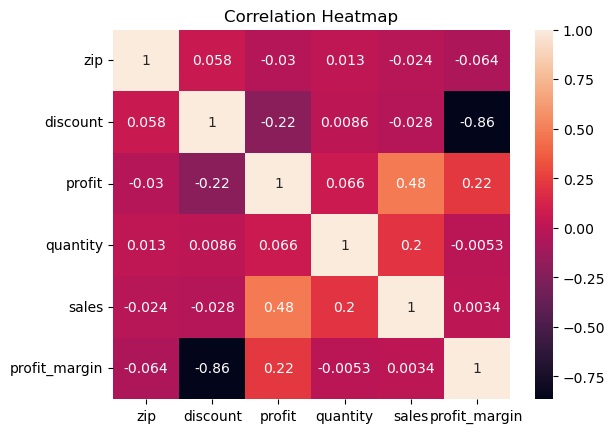

In [67]:
# Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()



- Some regions generate higher sales than others
- Sales show variation over time
- Certain categories contribute more revenue
- Profit differs across categories
- Few products generate most of the sales